In [4]:
! pip install optuna
! pip install xgboost
! pip install shap

In [5]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneGroupOut, cross_validate,  cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import optuna
import shap

In [6]:
def mean_wrinkler_score(y_true, y_pred_lo, y_pred_hi, alpha=0.2):
  scores = np.full(len(y_true), y_pred_hi - y_pred_lo)
  mask_lo = y_true < y_pred_lo
  scores[mask_lo] += (y_pred_lo[mask_lo] - y_true[mask_lo]) * (2/alpha)
  mask_hi = y_true > y_pred_hi
  scores[mask_hi] += (y_true[mask_hi] - y_pred_hi[mask_hi]) * (2/alpha)

  return np.mean(scores)

In [7]:
honey = pd.read_csv('honey.csv', sep=";")
weather = pd.read_csv('df_weekly_2019_2025.csv')
beehives = pd.read_csv('ule.csv', sep=";")

In [8]:
honey.head()

,year,week,honey,harvest
0,2019,30,66.0,1
1,2019,32,55.0,1
2,2019,33,134.0,2
3,2019,34,72.0,1
4,2019,35,59.0,1


In [9]:
beehives.head()

,year,beehive
0,2019,92
1,2020,86
2,2021,98
3,2022,100
4,2023,87


In [10]:
weather.head()

,year,month,week,temp,wspd,prcp,pres
0,2019,5,18,8.644572,2.952617,0.247276,940.72546
1,2019,5,19,8.801729,2.939627,0.163314,946.07404
2,2019,5,20,10.284056,2.588411,0.200703,949.08860
3,2019,5,21,13.292661,2.689059,0.371334,943.73720
4,2019,5,22,13.032857,2.948426,0.205314,949.50854


In [11]:
df = pd.merge(honey, weather, on=["year", "week"], how="inner")

In [12]:
df = pd.merge(df, beehives, on="year", how="inner")

In [13]:
weather_filtered = weather[(weather['week'] >= 18) & (weather['week'] <= 30)]

weather_filtered['feature_week'] = weather_filtered['week'].astype(str) + '_'
weather_pivot = weather_filtered.pivot_table(
    index='year',
    columns='feature_week',
    values=['temp', 'wspd', 'prcp', 'pres']
)

weather_pivot.columns = [f'{col[0]}_{col[1].replace("_", "")}' for col in weather_pivot.columns]

df = pd.merge(df, weather_pivot, on='year', how='left')
df.head()

,year,week,honey,harvest,month,temp,wspd,prcp,pres,beehive,...,wspd_21,wspd_22,wspd_23,wspd_24,wspd_25,wspd_26,wspd_27,wspd_28,wspd_29,wspd_30
0,2019,30,66.0,1,7,18.468962,2.068542,0.125877,949.43176,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
1,2019,32,55.0,1,8,19.387705,1.972191,0.171244,948.63810,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
2,2019,33,134.0,2,8,16.821316,1.924085,0.108202,949.98334,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
3,2019,34,72.0,1,8,18.534908,1.906017,0.032221,957.32385,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
4,2019,35,59.0,1,8,20.535137,1.664818,0.082062,955.53265,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542


In [14]:
df.columns

Index(['year', 'week', 'honey', 'harvest', 'month', 'temp', 'wspd', 'prcp',
       'pres', 'beehive', 'prcp_18', 'prcp_19', 'prcp_20', 'prcp_21',
       'prcp_22', 'prcp_23', 'prcp_24', 'prcp_25', 'prcp_26', 'prcp_27',
       'prcp_28', 'prcp_29', 'prcp_30', 'pres_18', 'pres_19', 'pres_20',
       'pres_21', 'pres_22', 'pres_23', 'pres_24', 'pres_25', 'pres_26',
       'pres_27', 'pres_28', 'pres_29', 'pres_30', 'temp_18', 'temp_19',
       'temp_20', 'temp_21', 'temp_22', 'temp_23', 'temp_24', 'temp_25',
       'temp_26', 'temp_27', 'temp_28', 'temp_29', 'temp_30', 'wspd_18',
       'wspd_19', 'wspd_20', 'wspd_21', 'wspd_22', 'wspd_23', 'wspd_24',
       'wspd_25', 'wspd_26', 'wspd_27', 'wspd_28', 'wspd_29', 'wspd_30'],
      dtype='str')

In [15]:
df.head()

,year,week,honey,harvest,month,temp,wspd,prcp,pres,beehive,...,wspd_21,wspd_22,wspd_23,wspd_24,wspd_25,wspd_26,wspd_27,wspd_28,wspd_29,wspd_30
0,2019,30,66.0,1,7,18.468962,2.068542,0.125877,949.43176,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
1,2019,32,55.0,1,8,19.387705,1.972191,0.171244,948.63810,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
2,2019,33,134.0,2,8,16.821316,1.924085,0.108202,949.98334,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
3,2019,34,72.0,1,8,18.534908,1.906017,0.032221,957.32385,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
4,2019,35,59.0,1,8,20.535137,1.664818,0.082062,955.53265,92,...,2.689059,2.589977,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542


In [16]:
corr = df.corr()
honey_corr = corr["honey"].sort_values(ascending=False)

honey_corr

honey      1.000000
harvest    0.488105
wspd       0.375382
prcp       0.323845
prcp_26    0.315445
             ...   
temp_29   -0.211350
temp_23   -0.247105
temp_21   -0.292423
temp      -0.301113
temp_22   -0.320457
Name: honey, Length: 62, dtype: float64

In [17]:
# cechy i target
features = [col for col in df.columns if col not in ["honey"]]

X = df[features]
y = df["honey"]

# walidacja po latach
groups = df["year"]
cv = LeaveOneGroupOut()

models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),

    "ElasticNet": Pipeline([ #polaczenie ridge i lasso 
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
    ]),

    "Huber": Pipeline([ # Huber gdy jsst duzo wartosci odstajacych 
        ("scaler", StandardScaler()),
        ("model", HuberRegressor(max_iter=1000))
    ]),

    "SVR": Pipeline([ #proba zanlezienia gladkiej nieliniowej funkcji, ktora przewiduje arget 
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, epsilon=10))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=2,
        random_state=42
    )
}

results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv.split(X, y, groups),
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        }
    )

    results.append({
        "model": name,
        "MAE": -scores["test_mae"].mean(),
        "RMSE": -scores["test_rmse"].mean()
    })

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,model,MAE,RMSE
0,Ridge,51.085568,64.836911
1,ElasticNet,52.109605,67.508195
5,ExtraTrees,54.017804,65.371281
4,RandomForest,55.740126,70.132730
6,GradientBoosting,56.996660,71.897193
2,Huber,58.676901,74.476754
3,SVR,64.295717,80.402975


In [18]:
month_groups = df["month"]
month_cv = LeaveOneGroupOut()

month_results = []
for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=month_cv.split(X, y, month_groups),
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        }
    )
    month_results.append({
        "model": name,
        "MAE": -scores["test_mae"].mean(),
        "RMSE": -scores["test_rmse"].mean()
    })

month_results_df = pd.DataFrame(month_results).sort_values("MAE")
month_results_df

,model,MAE,RMSE
0,Ridge,53.854762,72.649954
1,ElasticNet,55.748966,74.195105
5,ExtraTrees,58.152362,77.820017
2,Huber,60.277080,82.386410
4,RandomForest,61.161821,83.572226
6,GradientBoosting,61.229166,84.330001
3,SVR,75.507409,99.382418


In [19]:
cv = LeaveOneGroupOut()

def evaluate_model(model, X, y, groups):
    scores = cross_val_score(model, X, y,cv=cv.split(X, y, groups), scoring="neg_mean_absolute_error")
    
    return -scores.mean()

In [20]:
def objective_ridge(trial):

    alpha = trial.suggest_float("alpha", 0.001, 1000.0 , log = True )


    model = Pipeline([
        ("scaler" ,StandardScaler()),
        ("model",Ridge(alpha = alpha)),
    ])


    mae = evaluate_model(model, X, y, groups)

    return mae


find_ridge = optuna.create_study(direction="minimize")
find_ridge.optimize(objective_ridge,n_trials = 500)

[I 2026-05-13 00:26:27,706] A new study created in memory with name: no-name-f7b54812-ea33-47dd-b4ac-63db7d061b7f


[I 2026-05-13 00:26:27,740] Trial 0 finished with value: 56.300414543452234 and parameters: {'alpha': 0.022896203833990842}. Best is trial 0 with value: 56.300414543452234.
[I 2026-05-13 00:26:27,773] Trial 1 finished with value: 56.33077118368084 and parameters: {'alpha': 0.0016412375116212155}. Best is trial 0 with value: 56.300414543452234.
[I 2026-05-13 00:26:27,806] Trial 2 finished with value: 55.498919961138874 and parameters: {'alpha': 0.6661114448255905}. Best is trial 2 with value: 55.498919961138874.
[I 2026-05-13 00:26:27,838] Trial 3 finished with value: 50.47120855383259 and parameters: {'alpha': 13.22925506154688}. Best is trial 3 with value: 50.47120855383259.
[I 2026-05-13 00:26:27,871] Trial 4 finished with value: 49.555013199682 and parameters: {'alpha': 19.70334356756768}. Best is trial 4 with value: 49.555013199682.
[I 2026-05-13 00:26:27,903] Trial 5 finished with value: 56.28260026054162 and parameters: {'alpha': 0.03540462914396167}. Best is trial 4 with value: 

In [21]:
print("Best MAE Ridge:", find_ridge.best_value)
print("Best params Ridge:",find_ridge.best_params)

Best MAE Ridge: 48.77254533503933
Best params Ridge: {'alpha': 31.540736491813327}


In [22]:
def objective_ridge(trial):

    alpha = trial.suggest_float("alpha", 0.001, 1000.0 , log = True )


    model = Pipeline([
        ("scaler" ,StandardScaler()),
        ("model",Ridge(alpha = alpha)),
    ])


    mae = evaluate_model(model, X, y, month_groups)

    return mae


find_ridge = optuna.create_study(direction="minimize")
find_ridge.optimize(objective_ridge,n_trials = 500)

[I 2026-05-13 00:26:45,996] A new study created in memory with name: no-name-df103098-fd91-445d-828a-cc3fe2aca56e
[I 2026-05-13 00:26:46,022] Trial 0 finished with value: 58.04963152921804 and parameters: {'alpha': 0.0012219522900247136}. Best is trial 0 with value: 58.04963152921804.
[I 2026-05-13 00:26:46,044] Trial 1 finished with value: 58.026129202336115 and parameters: {'alpha': 0.014177535078920611}. Best is trial 1 with value: 58.026129202336115.
[I 2026-05-13 00:26:46,066] Trial 2 finished with value: 54.675187831833014 and parameters: {'alpha': 3.8009042365545875}. Best is trial 2 with value: 54.675187831833014.
[I 2026-05-13 00:26:46,088] Trial 3 finished with value: 58.046595742694436 and parameters: {'alpha': 0.0028896655069984823}. Best is trial 2 with value: 54.675187831833014.
[I 2026-05-13 00:26:46,111] Trial 4 finished with value: 74.49104312396636 and parameters: {'alpha': 368.4712925256312}. Best is trial 2 with value: 54.675187831833014.
[I 2026-05-13 00:26:46,134]

In [23]:
print("Best MAE Ridge:", find_ridge.best_value)
print("Best params Ridge:",find_ridge.best_params)

Best MAE Ridge: 53.68260524825854
Best params Ridge: {'alpha': 9.03770985081656}


In [24]:
def objective_elasticnet(trial):
    alpha = trial.suggest_float("alpha", 0.001, 100.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.01, 1.0)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=10000,
        random_state=42
        ))
    ])

    mae = evaluate_model(model, X, y, groups)

    return mae

study_elasticnet = optuna.create_study(direction="minimize")
study_elasticnet.optimize(objective_elasticnet, n_trials=400)


[I 2026-05-13 00:26:57,651] A new study created in memory with name: no-name-a506b10c-f053-4217-a1dd-871ba203205b


[I 2026-05-13 00:26:57,697] Trial 0 finished with value: 52.334276679121125 and parameters: {'alpha': 4.590486616357229, 'l1_ratio': 0.8163175635449209}. Best is trial 0 with value: 52.334276679121125.
[I 2026-05-13 00:26:57,851] Trial 1 finished with value: 53.56075152766106 and parameters: {'alpha': 0.010617309489965171, 'l1_ratio': 0.6517408581313816}. Best is trial 0 with value: 52.334276679121125.
/home/patka/bee-trajectory-simulation/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.504e+04, tolerance: 4.043e+01
  model = cd_fast.enet_coordinate_descent(
/home/patka/bee-trajectory-simulation/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of i

In [25]:
print("Best MAE ElasticNet:", study_elasticnet.best_value)
print("Best params ElasticNet:", study_elasticnet.best_params)

Best MAE ElasticNet: 47.15937407230641
Best params ElasticNet: {'alpha': 2.7931602322781006, 'l1_ratio': 0.9859338892060554}


In [26]:
def objective_elasticnet(trial):
    alpha = trial.suggest_float("alpha", 0.001, 100.0, log=True)
    l1_ratio = trial.suggest_float("l1_ratio", 0.01, 1.0)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=10000,
        random_state=42
        ))
    ])

    mae = evaluate_model(model, X, y, month_groups)

    return mae

study_elasticnet = optuna.create_study(direction="minimize")
study_elasticnet.optimize(objective_elasticnet, n_trials=400)

[I 2026-05-13 00:27:14,385] A new study created in memory with name: no-name-2444d4ca-c4ce-4626-8384-47af0f1c6f0d
[I 2026-05-13 00:27:14,413] Trial 0 finished with value: 75.94080314756556 and parameters: {'alpha': 29.236046149194472, 'l1_ratio': 0.05417518693886572}. Best is trial 0 with value: 75.94080314756556.
[I 2026-05-13 00:27:14,439] Trial 1 finished with value: 76.32108611276986 and parameters: {'alpha': 41.59180654296186, 'l1_ratio': 0.8707413002150015}. Best is trial 0 with value: 75.94080314756556.
[I 2026-05-13 00:27:14,480] Trial 2 finished with value: 56.90286301765339 and parameters: {'alpha': 0.23483375385524016, 'l1_ratio': 0.9743222462362744}. Best is trial 2 with value: 56.90286301765339.
[I 2026-05-13 00:27:14,512] Trial 3 finished with value: 56.678090335539316 and parameters: {'alpha': 0.08648098084157033, 'l1_ratio': 0.7559615169905558}. Best is trial 3 with value: 56.678090335539316.
[I 2026-05-13 00:27:14,595] Trial 4 finished with value: 57.23506329508645 and

In [27]:
print("Best MAE ElasticNet:", study_elasticnet.best_value)
print("Best params ElasticNet:", study_elasticnet.best_params)

Best MAE ElasticNet: 53.12613243610028
Best params ElasticNet: {'alpha': 5.348384694855982, 'l1_ratio': 0.9999128541577181}


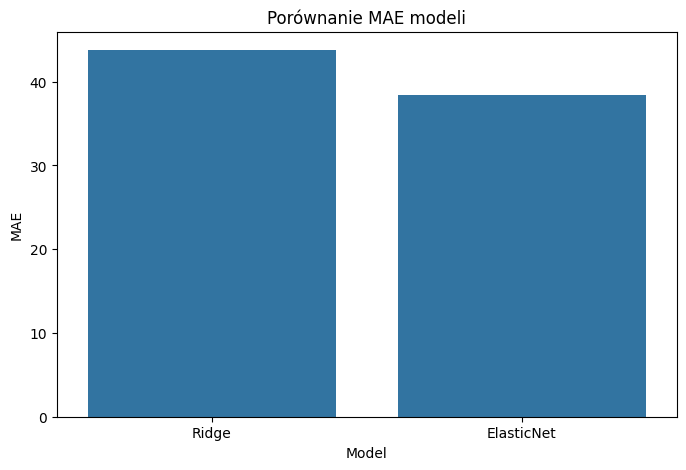

In [28]:
results = pd.DataFrame({
    "model": ["Ridge", "ElasticNet"],
    "MAE": [43.76986154303357, 38.42697347625917]
})

plt.figure(figsize=(8,5))
sns.barplot(data=results, x="model", y="MAE")
plt.title("Porównanie MAE modeli")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.show()

In [29]:
best_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=4.3981810937396855,
        l1_ratio=0.997928523653379,
        max_iter=10000,
        random_state=42
    ))
])



cv = LeaveOneGroupOut()

In [30]:
from sklearn.model_selection import cross_val_predict
y_pred_elastic = cross_val_predict(best_elastic, X, y, cv = cv.split(X,y,groups))

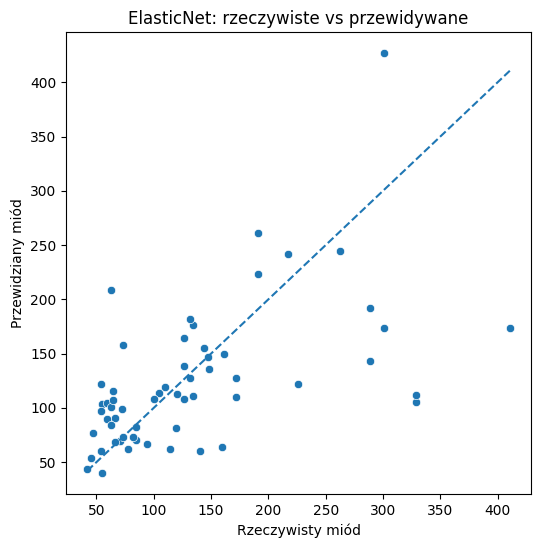

In [31]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_elastic)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
plt.xlabel("Rzeczywisty miód")
plt.ylabel("Przewidziany miód")
plt.title("ElasticNet: rzeczywiste vs przewidywane")
plt.show()

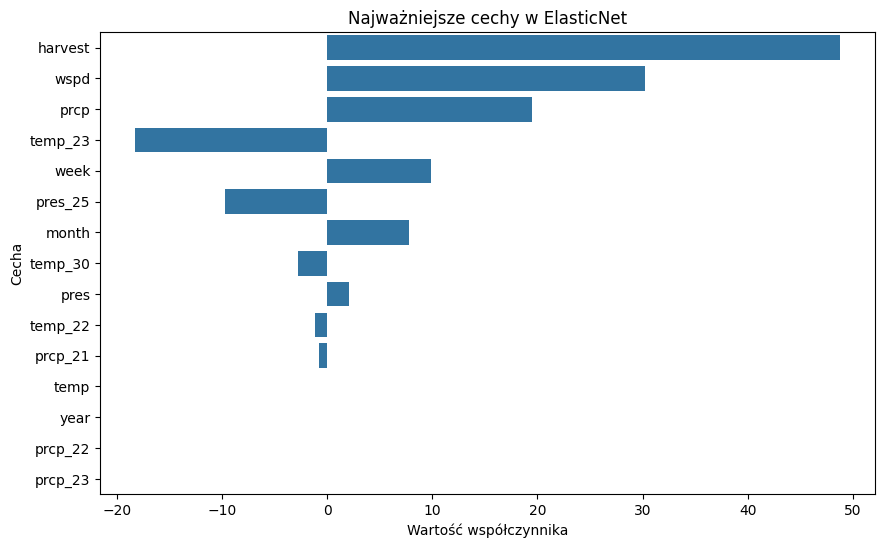

In [32]:
best_elastic.fit(X, y)

coefs = pd.DataFrame({
    "feature": X.columns,
    "coef": best_elastic.named_steps["model"].coef_
})

coefs["abs_coef"] = coefs["coef"].abs()
coefs = coefs.sort_values("abs_coef", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=coefs, x="coef", y="feature")
plt.title("Najważniejsze cechy w ElasticNet")
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cecha")
plt.show()

In [33]:
best_elastic.fit(X, y)
scaler = best_elastic.named_steps["scaler"]
model = best_elastic.named_steps["model"]

X_scaled = scaler.transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

In [34]:
explainer = shap.LinearExplainer(model, X_scaled_df)
shap_values = explainer(X_scaled_df)

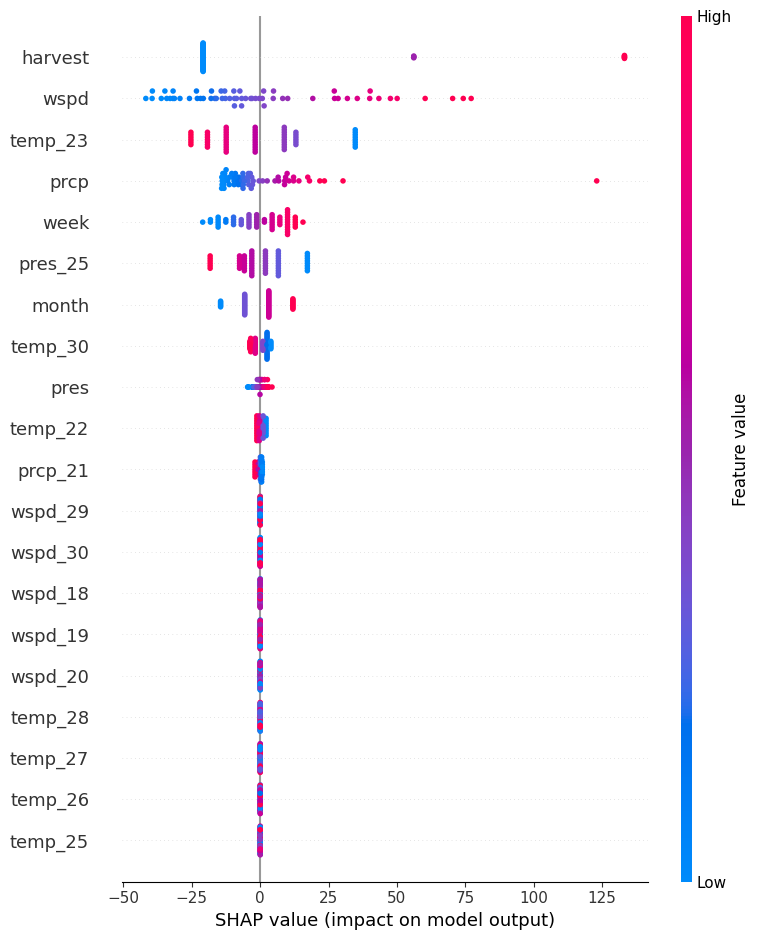

In [35]:
shap.summary_plot(shap_values, X_scaled_df)

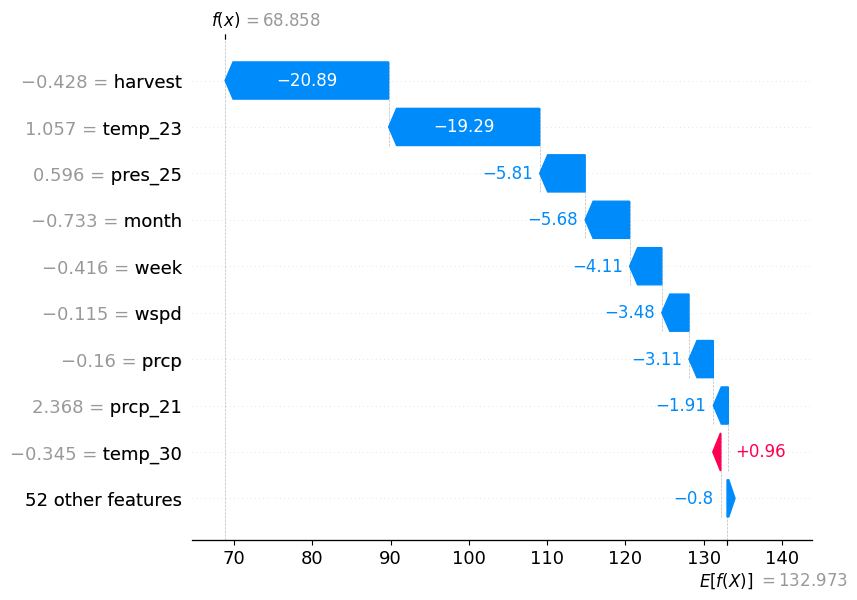

In [36]:
shap.plots.waterfall(shap_values[0])

In [37]:
df_check = X.copy()
df_check["true_honey"] = y
df_check["predicted_honey"] = best_elastic.predict(X)

df_check[["year", "week", "harvest", "true_honey", "predicted_honey"]].head(15)

,year,week,harvest,true_honey,predicted_honey
0,2019,30,1,66.0,68.857514
1,2019,32,1,55.0,80.636179
2,2019,33,2,134.0,152.693602
3,2019,34,1,72.0,75.046970
4,2019,35,1,59.0,65.707236
5,2019,35,1,59.0,79.101479
6,2019,36,1,147.0,122.614366
7,2020,26,2,410.9,301.039522
8,2020,29,1,63.0,140.507287
9,2020,30,1,140.0,119.080666


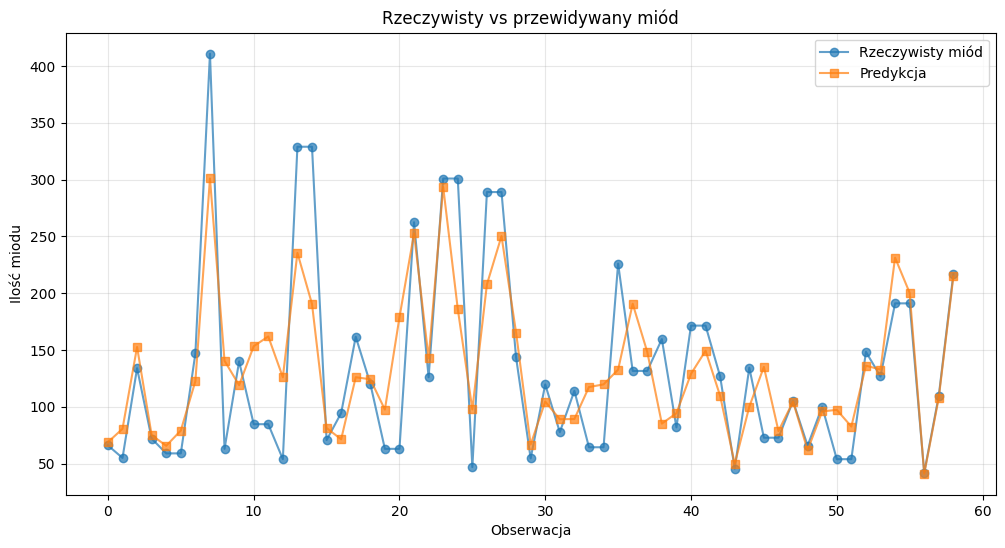

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(df_check["true_honey"].values, label="Rzeczywisty miód", marker='o', alpha=0.7)
plt.plot(df_check["predicted_honey"].values, label="Predykcja", marker='s', alpha=0.7)
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.xlabel("Obserwacja")
plt.ylabel("Ilość miodu")
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
df_check["error"] = df_check["predicted_honey"] - df_check["true_honey"]
df_check["abs_error"] = df_check["error"].abs()
df_check["rel_error_pct"] = 100 * df_check["abs_error"] / df_check["true_honey"].replace(0, np.nan)

print("Mean absolute error:", round(df_check["abs_error"].mean(), 2))
print("Max absolute error:", round(df_check["abs_error"].max(), 2))

worst = df_check.sort_values("abs_error", ascending=False).head(10)
print("\nTop 10 największych błędów:")
worst[["year", "week", "true_honey", "predicted_honey", "error", "abs_error", "rel_error_pct"]]

Mean absolute error: 35.5
Max absolute error: 138.45

Top 10 największych błędów:


,year,week,true_honey,predicted_honey,error,abs_error,rel_error_pct
14,2020,36,329.0,190.547433,-138.452567,138.452567,42.082847
20,2021,30,63.0,178.787922,115.787922,115.787922,183.790352
24,2021,35,301.0,186.212316,-114.787684,114.787684,38.135443
7,2020,26,410.9,301.039522,-109.860478,109.860478,26.736549
13,2020,36,329.0,235.536709,-93.463291,93.463291,28.408295
35,2022,36,226.1,132.738047,-93.361953,93.361953,41.292328
26,2022,26,289.1,207.821287,-81.278713,81.278713,28.114394
8,2020,29,63.0,140.507287,77.507287,77.507287,123.027439
11,2020,31,84.7,161.949817,77.249817,77.249817,91.204034
38,2023,27,159.6,85.218128,-74.381872,74.381872,46.605183


In [ ]:
year_errors = df_check.groupby("year")["abs_error"].mean().reset_index()
year_errors.columns = ["year", "mean_abs_error"]

year_errors["mean_abs_error"] = year_errors["mean_abs_error"].round(2)
print("Średni błąd bezwzględny (MAE) na rok:")
year_errors

Średni błąd bezwzględny (MAE) na rok:


,year,mean_abs_error
0,2019,14.49
1,2020,82.28
2,2021,37.24
3,2022,41.63
4,2023,37.88
5,2024,19.71
6,2025,10.08


In [51]:
year_summary = df_check.groupby("year").agg(
    actual_sum=("true_honey", "sum"),
    predicted_sum=("predicted_honey", "sum"),
).reset_index()

year_summary["actual_sum"] = year_summary["actual_sum"].round(2)
year_summary["predicted_sum"] = year_summary["predicted_sum"].round(2)
print("Suma rzeczywistego i przewidywanego miodu na rok:")
year_summary[["year", "actual_sum", "predicted_sum"]]

Suma rzeczywistego i przewidywanego miodu na rok:


,year,actual_sum,predicted_sum
0,2019,592.0,644.66
1,2020,1495.2,1428.04
2,2021,1563.8,1554.49
3,2022,1489.6,1440.85
4,2023,847.7,797.00
5,2024,979.3,1051.87
6,2025,877.8,928.49


In [49]:
year_beehive_summary = df_check.groupby(["year", "beehive"]).agg(
    actual_sum=("true_honey", "sum"),
    predicted_sum=("predicted_honey", "sum"),
).reset_index()

year_beehive_summary["actual_sum"] = year_beehive_summary["actual_sum"]/year_beehive_summary["beehive"]
year_beehive_summary["predicted_sum"] = year_beehive_summary["predicted_sum"]/year_beehive_summary["beehive"]
print("Suma rzeczywista i przewidywana na ul:")
year_beehive_summary.sort_values(["year", "beehive"]).head(20)

Suma rzeczywista i przewidywana na ul:


,year,beehive,actual_sum,predicted_sum
0,2019,92,6.434783,7.007145
1,2020,86,17.386047,16.605071
2,2021,98,15.957143,15.862161
3,2022,100,14.896000,14.408466
4,2023,87,9.743678,9.160944
5,2024,100,9.793000,10.518728
6,2025,96,9.143750,9.671804
